Part 1: Analyzing Best-Seller Trends Across Product Categories
Objective: Understand the relationship between product categories and their best-seller status.

Crosstab Analysis:

-Create a crosstab between the product category and the isBestSeller status.

Are there categories where being a best-seller is more prevalent?

Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.

Statistical Tests:

Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
Compute Cramér's V to understand the strength of association between best-seller status and category.
Visualizations:

Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

----------

Part 2: Exploring Product Prices and Ratings Across Categories and Brands

Objective: Investigate how different product categories influence product prices.

Preliminary Step: Remove outliers in product prices.

For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.


Violin Plots:

Use a violin plot to visualize the distribution of price across different product categories. Filter out the top 20 categories based on count for better visualization.
Which product category tends to have the highest median price? Don't filter here by top categories.
Bar Charts:

Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
Which product category commands the highest average price? Don't filter here by top categories.
Box Plots:

Visualize the distribution of product ratings based on their category using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

------------

Part 3: Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

Correlation Coefficients:

Calculate the correlation coefficient between price and stars.
Is there a significant correlation between product price and its rating?
Visualizations:

Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
Use a correlation heatmap to visualize correlations between all numerical variables.
Examine if product prices typically follow a normal distribution using a QQ plot.


In [1]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

In [2]:
df= pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [3]:
df.head(10)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


In [4]:
#Part 1

#crosstab analysis 

best_seller_groupby = df.groupby('category')['isBestSeller'].mean() * 100

best_seller_groupby = best_seller_groupby.sort_values (ascending = False)

print ("Top 10 Categories by Percentage of Best-Sellers (Groupby Method): ")
print (best_seller_groupby.head(10))



Top 10 Categories by Percentage of Best-Sellers (Groupby Method): 
category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Name: isBestSeller, dtype: float64


--- Statistical Tests ---
Chi-Square Statistic: 36540.20
P-value: 0.0000e+00
Cramér's V: 0.1223



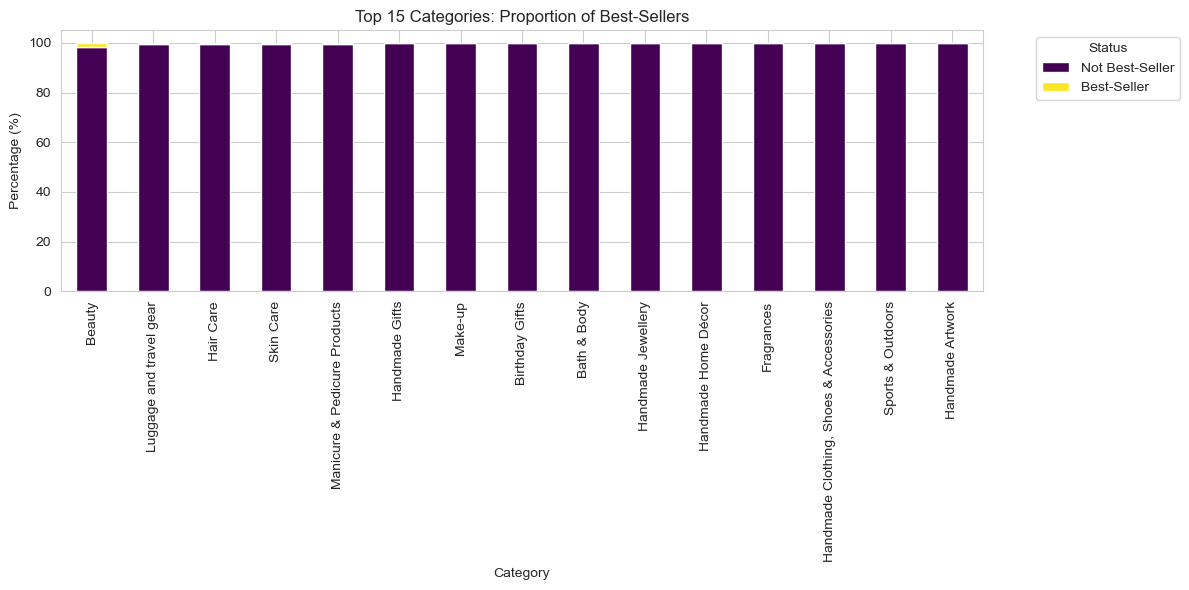

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import scipy.stats as stats 

# --- 1. Statistical Tests ---
# Step A: Create a raw frequency crosstab (do NOT use normalize='index' for Chi-Square)
contingency_table = pd.crosstab(df['category'], df['isBestSeller'])

# Step B: Run the Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("--- Statistical Tests ---")
print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4e}")

# Step C: Calculate Cramér's V
n = contingency_table.sum().sum() # Total number of observations
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)
cramer_v = np.sqrt(chi2 / (n * min_dim))

print(f"Cramér's V: {cramer_v:.4f}\n")


# --- 2. Stacked Bar Chart Visualization ---
# Plotting 296 categories is unreadable. We will filter to the Top 15 categories by volume.
top_15_cats = df['category'].value_counts().head(15).index

# Create a normalized crosstab just for these 15 categories
vis_crosstab = pd.crosstab(df[df['category'].isin(top_15_cats)]['category'], 
                           df[df['category'].isin(top_15_cats)]['isBestSeller'], 
                           normalize='index') * 100

vis_crosstab.columns = ['Not Best-Seller', 'Best-Seller']
vis_crosstab = vis_crosstab.sort_values('Best-Seller', ascending=False)

# Plotting
vis_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Top 15 Categories: Proportion of Best-Sellers')
plt.xlabel('Category')
plt.ylabel('Percentage (%)')

# Move the legend outside the chart so it doesn't block the bars
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---

#### PART 2 

In [6]:
# 1. Calculate Q1, Q3, and the Interquartile Range (IQR)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the bounds based on your instruction: 1.5 times the IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Create the new dataset WITH NO OUTLIERS
df_clean_price = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_19756/3086178620.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top_20, x='price', y='category', palette="muted")


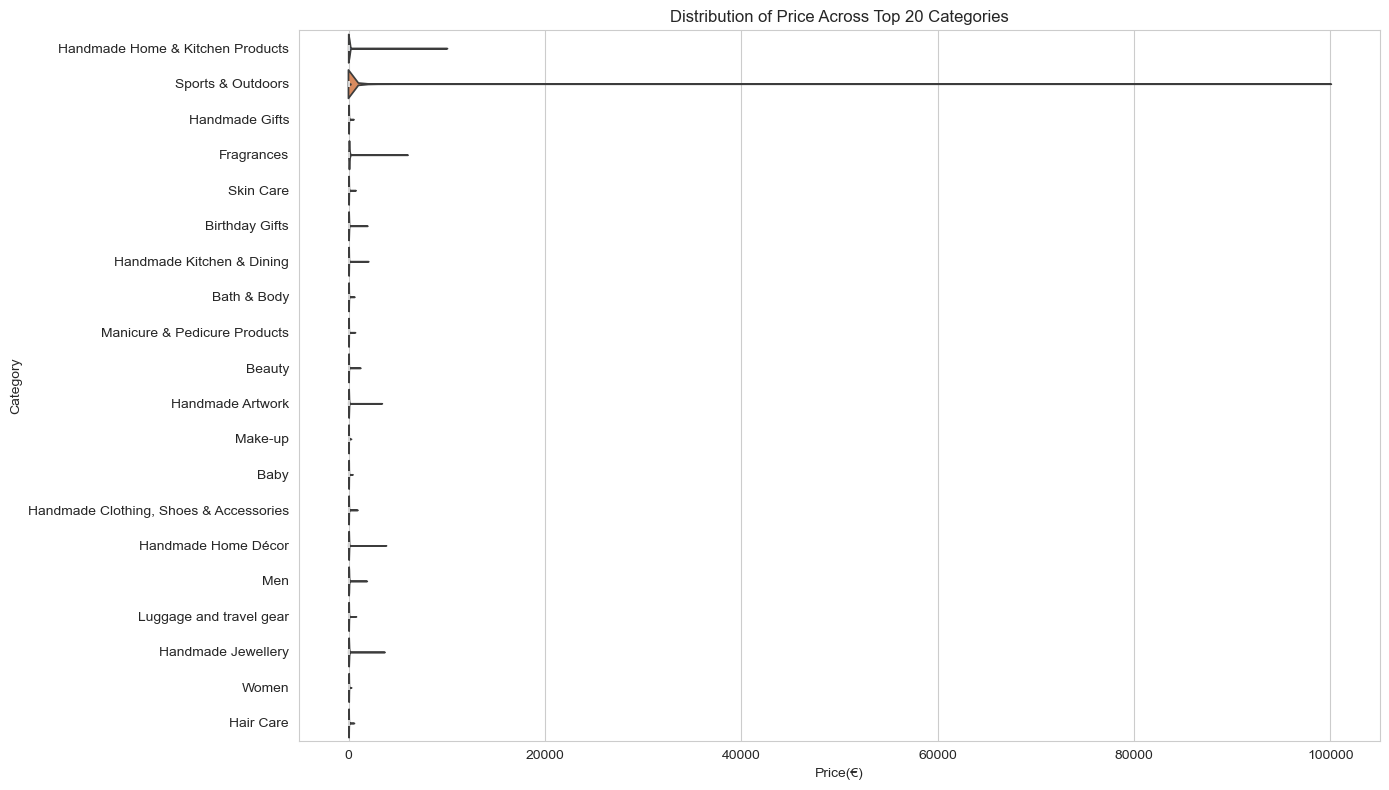

--- Unfiltered Analysis
Category with Highest Median Price:
category
Laptops    1042.725
Name: price, dtype: float64



In [7]:
##Violin plots 

top_20_cats = df['category'].value_counts().head(20).index
df_top_20= df[df['category'].isin(top_20_cats)]

plt.figure(figsize=(14,8))
sns.violinplot(data=df_top_20, x='price', y='category', palette="muted")
plt.title('Distribution of Price Across Top 20 Categories')
plt.xlabel('Price(€)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

#Answer: Which product category tends to have the highest median price? 

highest_median_price_cat= df.groupby('category')['price'].median().sort_values(ascending=False).head(1)
print (f"--- Unfiltered Analysis")
print (f"Category with Highest Median Price:\n{highest_median_price_cat}\n")

/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_19756/2560555306.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='category', data=df_top_10, palette='Set2')


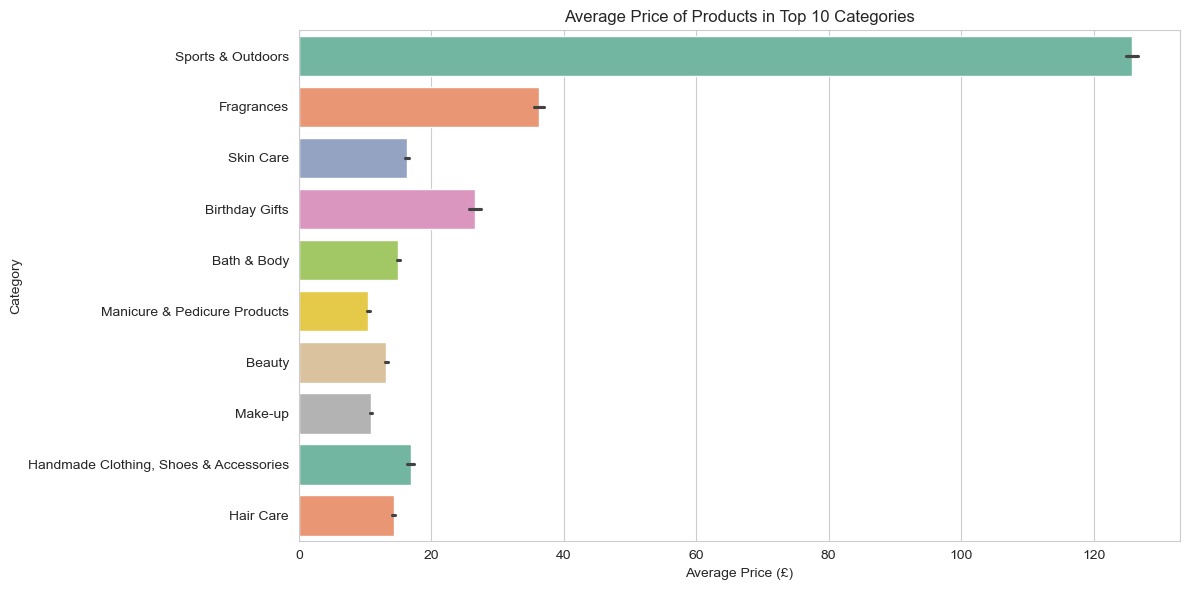

Category with Highest Average Price:
category
Laptops    1087.987827
Name: price, dtype: float64



In [8]:
#Bar Charts: Average Price 

# Filter out the top 10 categories based on count
top_10_cats = df['category'].value_counts().head(10).index
df_top_10 = df[df['category'].isin(top_10_cats)]

plt.figure(figsize=(12, 6))
# sns.barplot defaults to calculating the mean (average)
sns.barplot(x='price', y='category', data=df_top_10, palette='Set2')
plt.title('Average Price of Products in Top 10 Categories')
plt.xlabel('Average Price (£)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Answer: Which product category commands the highest average price? (UNFILTERED)
highest_avg_price_cat = df.groupby('category')['price'].mean().sort_values(ascending=False).head(1)
print(f"Category with Highest Average Price:\n{highest_avg_price_cat}\n")

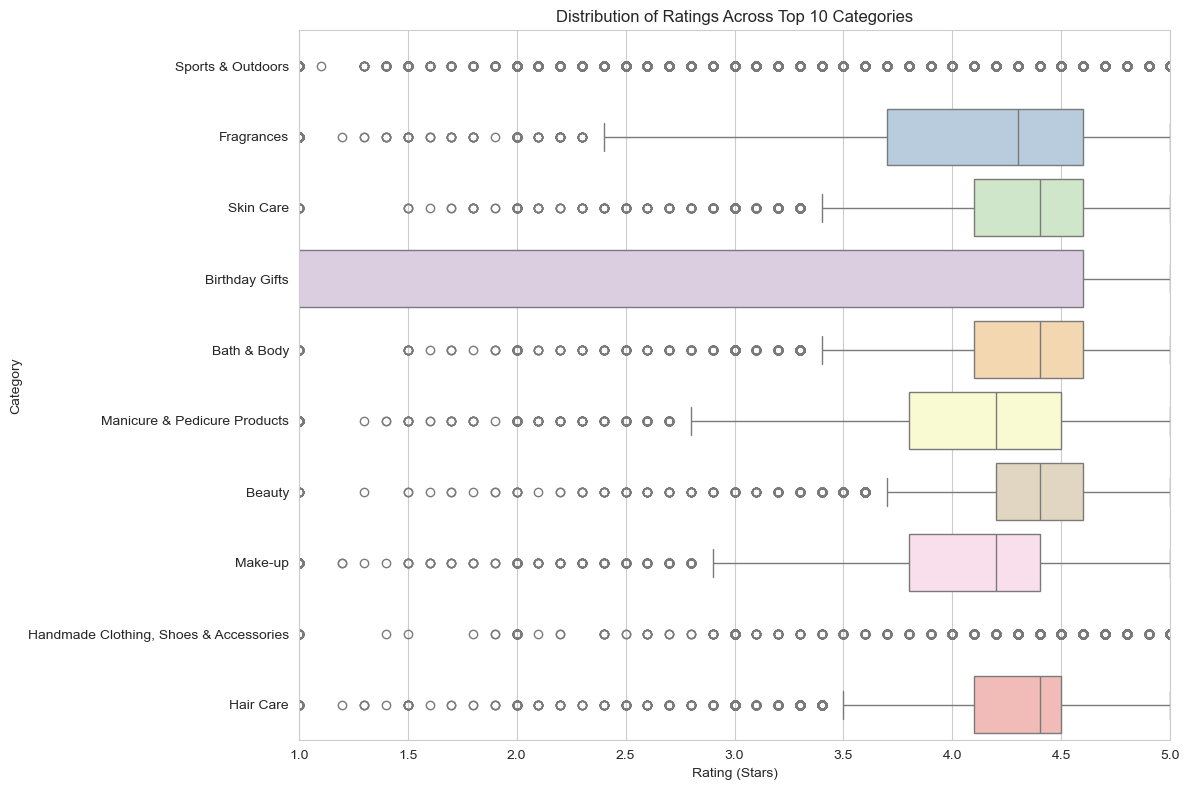

In [11]:
#Boxplots 

top_10_cats = df['category'].value_counts().head(10).index

# Filter the dataset to only include those top 10 categories
df_top_10 = df[df['category'].isin(top_10_cats)]

plt.figure(figsize=(12, 8))

# We use hue='category' and legend=False to prevent the Seaborn deprecation warning!
sns.boxplot(x='stars', y='category', data=df_top_10, hue='category', palette='Pastel1', legend=False)

plt.title('Distribution of Ratings Across Top 10 Categories')
plt.xlabel('Rating (Stars)')
plt.ylabel('Category')

# Lock the x-axis to the true 1 to 5 star rating scale for readability
plt.xlim(1, 5) 

plt.tight_layout()
plt.show()


---

#### PART 3

In [9]:
correlation = df['price'].corr(df['stars'])
print (f"Correlation coefficient between price and stars:{correlation: .4f}\n")

correlation_spear = df['price'].corr(df['stars'], method='spearman')
print (f"Spear Correlation coefficient between price and stars:{correlation_spear: .4f}\n")

Correlation coefficient between price and stars:-0.1249

Spear Correlation coefficient between price and stars:-0.1332



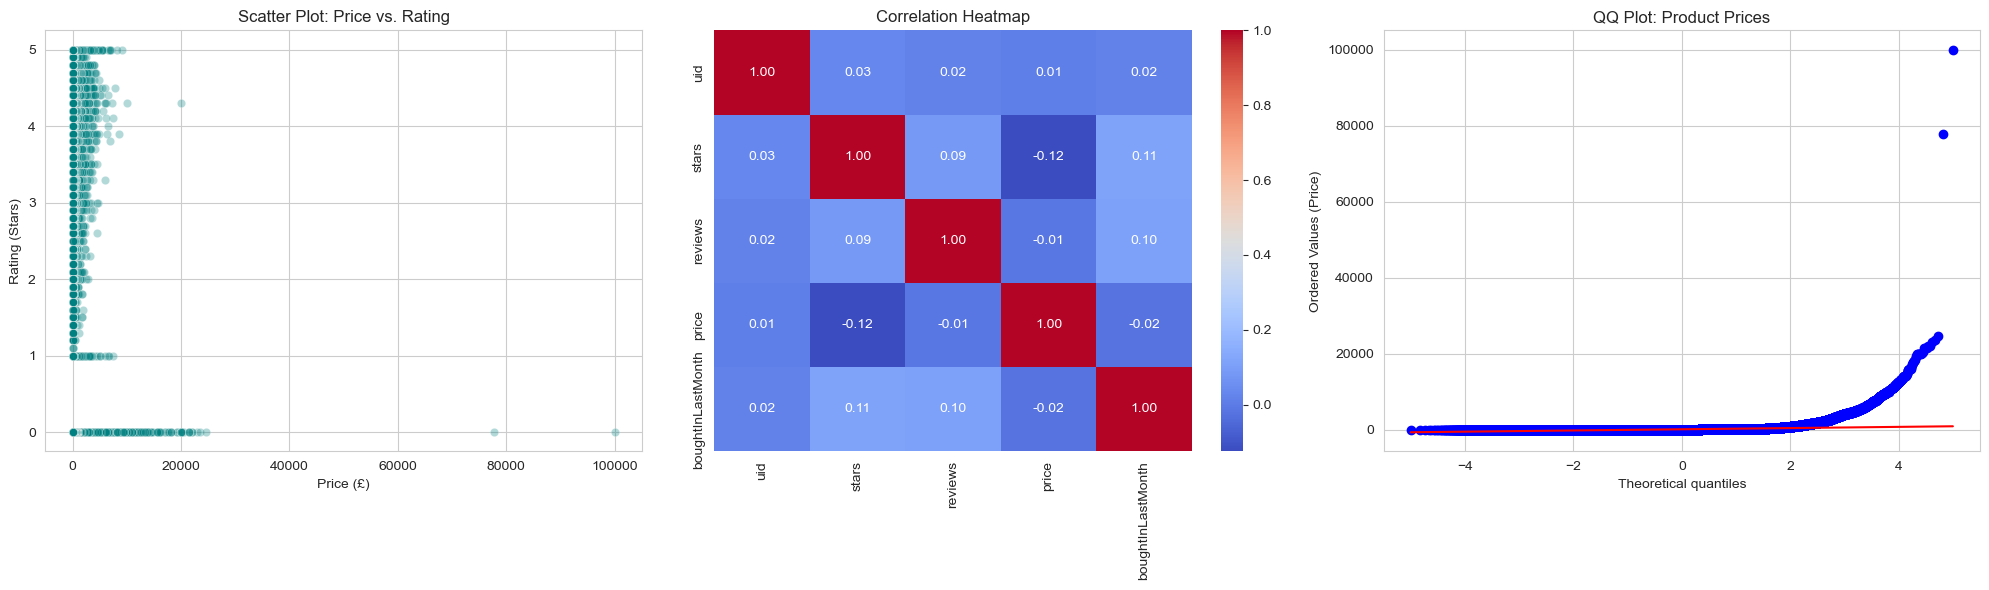

In [10]:
# 2. VISUALIZATIONS
# ==========================================
# Set up a 1x3 grid for our charts
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. Scatter Plot
sns.scatterplot(x='price', y='stars', data=df, alpha=0.3, ax=axes[0], color='teal')
axes[0].set_title('Scatter Plot: Price vs. Rating')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Rating (Stars)')

# B. Correlation Heatmap
# Select only numerical columns for the heatmap to avoid errors
numerical_cols = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Correlation Heatmap')

# C. QQ Plot (Quantile-Quantile Plot)
stats.probplot(df['price'], dist="norm", plot=axes[2])
axes[2].set_title('QQ Plot: Product Prices')
axes[2].set_ylabel('Ordered Values (Price)')

plt.tight_layout()
plt.show()